In [1]:
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import Optional
import ast
from collections import Counter, defaultdict
import random

pesto_cutoff = 70
plddt_cutoff = 70

In [4]:
uniprot_human_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_model_organism_9606_2024_12_16.tsv", sep="\t", usecols=['Entry', 'Entry Name', 'Protein names', 'Gene Names'])
uniprot_to_gene = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Gene Names']))
uniprot_to_protein_name = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Protein names']))

with open("chosen_diseases.txt", "r") as f:
    chosen_disease_names = [x.strip() for x in f.readlines()]

disease_associations = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network/open_target_2024_09/association_by_overall_indirect_disease_counts_cutoff_0.5.csv')
disease_associations = disease_associations[disease_associations['diseaseName'].isin(chosen_disease_names)]
disease_id_to_name = dict(zip(disease_associations['diseaseId'], disease_associations['diseaseName']))
disease_name_to_id = dict(zip(disease_associations['diseaseName'], disease_associations['diseaseId']))
print("Number of unique diseases: ", len(disease_associations['diseaseId'].unique()))

Number of unique diseases:  82


In [6]:
disease_associations

,diseaseId,targetId,score,evidenceCount,uniprot_targetId,diseaseName
2951,MONDO_0015909,ENSG00000008988,0.583261,13,P60866,aplastic anemia
2952,MONDO_0015909,ENSG00000012048,0.828619,396,P38398,aplastic anemia
2953,MONDO_0015909,ENSG00000012061,0.506229,27,P07992,aplastic anemia
2954,MONDO_0015909,ENSG00000051180,0.729512,112,Q06609,aplastic anemia
2955,MONDO_0015909,ENSG00000063177,0.500341,6,Q07020,aplastic anemia
...,...,...,...,...,...,...
182470,EFO_1002049,ENSG00000239732,0.544995,126,Q9NR96,glomerular disease
182471,EFO_1002049,ENSG00000244414,0.587819,67,Q03591,glomerular disease
182869,EFO_1002049,ENSG00000138760,0.695206,118,Q14108,glomerular disease
182870,EFO_1002049,ENSG00000148204,0.821178,73,Q5IJ48,glomerular disease


In [9]:
modality_counts = pd.read_csv(f"/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/case_studies/atomica_net/modality_chosen_disease_counts_pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_fix_irreps_ensemble.csv")
modality_counts

,diseaseId,modality,num_proteins,diseaseName
0,OTAR_0000020,protein,1162,nutritional or metabolic disease
1,OTAR_0000020,lipid,634,nutritional or metabolic disease
2,OTAR_0000020,nucleic_acid,350,nutritional or metabolic disease
3,OTAR_0000020,ligand,613,nutritional or metabolic disease
4,OTAR_0000020,ion,490,nutritional or metabolic disease
...,...,...,...,...
520,EFO_0003872,protein,16,colitis
521,EFO_0003872,lipid,13,colitis
522,EFO_0003872,nucleic_acid,8,colitis
523,EFO_0003872,ligand,7,colitis


In [13]:
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/case_studies/atomica_net/modality_graphs_20250308.pkl", "rb") as f:
    similar_modality_graphs = pickle.load(f)

In [14]:
embeddings_data_dirs = [
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/embeddings_fixed_irreps_v1/",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/embeddings_fixed_irreps_v2/",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/embeddings_fixed_irreps_v3/",
]

# Cosine similarity v.s. probability of being in the same disease

In [15]:
disease_bin_counts = defaultdict(list)
percentiles = np.arange(0, 101, 10)

modalities = ['protein', 'lipid', 'nucleic_acid', 'ion', 'ligand']
for modality in modalities:
    similarity_matrices = []
    uniprot_to_node_idxs = []
    for embeddings_data_dir in embeddings_data_dirs:
        with open(os.path.join(embeddings_data_dir, f"pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_{modality}.pkl"), "rb") as f:
            embeddings_dataset = pickle.load(f)

        embeddings = np.array([x['graph_embedding'] for x in embeddings_dataset])
        uniprot_to_node_idx = {x['id']: i for i, x in enumerate(embeddings_dataset)}
        node_idx_to_uniprot = {i: x['id'] for i, x in enumerate(embeddings_dataset)}
        uniprot_to_node_idxs.append(uniprot_to_node_idx)

        similarity_matrix = cosine_similarity(embeddings)
        similarity_matrices.append(similarity_matrix)
    
    assert list(uniprot_to_node_idxs[0].keys()) == list(uniprot_to_node_idxs[1].keys()) == list(uniprot_to_node_idxs[2].keys())
    similarity_matrix = np.mean(similarity_matrices, axis=0)

    rows, cols = np.triu_indices_from(similarity_matrix, k=1)

    valid_disease_ids = modality_counts[(modality_counts['modality'] == modality) & (modality_counts['num_proteins']>=25)]['diseaseId'].tolist()
    protein_disease_associations = disease_associations[disease_associations['diseaseId'].isin(valid_disease_ids)].groupby('uniprot_targetId')['diseaseId'].agg(set).to_dict()

    similarity_values = similarity_matrix[rows, cols]
    quantile_cutoffs = np.percentile(similarity_values, percentiles)

    for i in tqdm(range(len(quantile_cutoffs) - 1), desc=modality, total=len(quantile_cutoffs) - 1):
        a, b = quantile_cutoffs[i], quantile_cutoffs[i+1]
        values = similarity_matrix[rows, cols]
        mask = (values >= a) & (values <= b)
        for node1, node2 in zip(rows[mask], cols[mask]):
            uniprot1 = node_idx_to_uniprot[node1]
            uniprot2 = node_idx_to_uniprot[node2]
            diseases1 = protein_disease_associations.get(uniprot1, set())
            diseases2 = protein_disease_associations.get(uniprot2, set())
            if len(diseases1.intersection(diseases2)) > 0:
                disease_bin_counts[(modality, a, b, percentiles[i], percentiles[i+1])].append(1)
            else:
                disease_bin_counts[(modality, a, b, percentiles[i], percentiles[i+1])].append(0)

ligand: 100%|██████████| 10/10 [00:20<00:00,  2.06s/it]


In [16]:
disease_bin_counts_df = []
for (modality, a, b, percentile_a, percentile_b), counts in disease_bin_counts.items():
    disease_bin_counts_df.append({
        'modality': modality,
        'cosine_similarity_bin': f"{a:.2f}-{b:.2f}",
        'percentile_bin': f"{percentile_a}-{percentile_b}",
        'midpoint': (percentile_a + percentile_b) / 2,
        'total': len(counts),
        'mean': np.mean(counts),
        'std': np.std(counts),
    })
disease_bin_counts_df = pd.DataFrame(disease_bin_counts_df)

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/

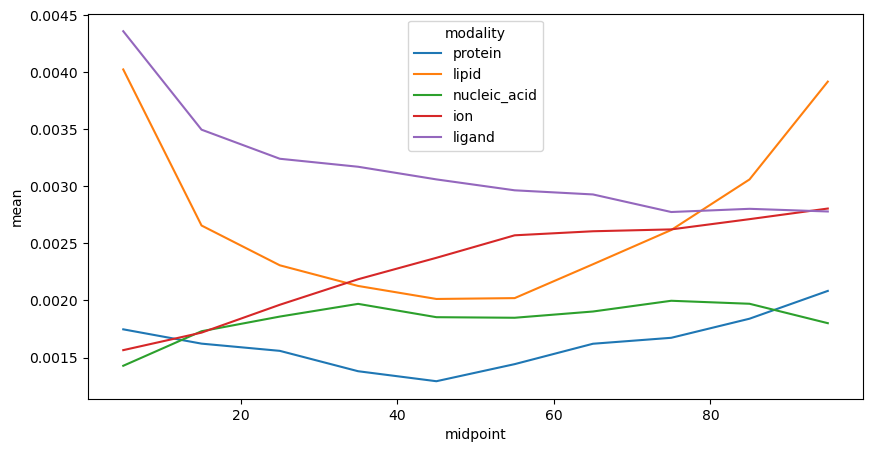

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(data=disease_bin_counts_df, x='midpoint', y='mean', hue='modality', ax=ax)
for modality in disease_bin_counts_df['modality'].unique():
    data = disease_bin_counts_df[disease_bin_counts_df['modality'] == modality]
plt.show()

## view all protein pairs

these values based on edge v.s. no edge differ slightly from the ones below which plots cosine similarity v.s. same disease probability because the interfacome nework has been pruned to make sure the maximum degree is 50.

In [18]:
for modality in ['protein', 'lipid', 'nucleic_acid', 'ion', 'ligand']:
    results = pd.read_csv(f"results/protein_pairs_{modality}.csv")
    print(modality)
    print(results.groupby(['edge']).agg({'disease_association': ['mean', 'std']}))

protein
     disease_association          
                    mean       std
edge                              
0               0.001626  0.040291
1               0.001706  0.041270
lipid
     disease_association          
                    mean       std
edge                              
0               0.001769  0.042020
1               0.003088  0.055482
nucleic_acid
     disease_association          
                    mean       std
edge                              
0               0.001777  0.042113
1               0.002766  0.052525
ion
     disease_association          
                    mean       std
edge                              
0               0.001829  0.042723
1               0.002861  0.053416
ligand
     disease_association          
                    mean       std
edge                              
0               0.001928  0.043862
1               0.002852  0.053331


In [74]:
modality_cutoff = {
    "protein": 0.98,
    "lipid": 0.975,
    "nucleic_acid": 0.971,
    "ligand": 0.969,
    "ion": 0.963,
}

agg_results = []
overall_probability = []

for modality in ['protein', 'lipid', 'nucleic_acid', 'ion', 'ligand']:
    results = pd.read_csv(f"results/protein_pairs_{modality}.csv")
    cosine_similarity_cutoff = modality_cutoff[modality]
    cosine_similarity_quantile = sum(results['cosine_similarity'] >= cosine_similarity_cutoff) / len(results)
    # max_percentile = 100-cosine_similarity_quantile*100
    # percentiles = np.arange(0, max_percentile, max_percentile/20)
    # percentiles = np.concatenate([percentiles, [max_percentile, 100]])

    percentiles = np.arange(0, 101, 5)

    print(f"{modality} {cosine_similarity_cutoff} {cosine_similarity_quantile}")
    quantile_cutoffs = np.percentile(results['cosine_similarity'], percentiles)
    results['quantile_bin'] = pd.cut(results['cosine_similarity'], bins=quantile_cutoffs, right=False)
    results['quantile_bin'] = results['quantile_bin'].astype(str)
    statistics = results.groupby('quantile_bin')['disease_association'].agg(['mean', 'std', 'count']).reset_index()
    statistics['modality'] = modality
    agg_results.append(statistics)

    overall_probability.append({
        'modality': modality,
        'probability': results['disease_association'].mean(),
        'std': results['disease_association'].std(),
        'count': len(results),
    })
agg_results = pd.concat(agg_results)
overall_probability = pd.DataFrame(overall_probability)

protein 0.98 0.03467170570796558
lipid 0.975 0.04348842538523595
nucleic_acid 0.971 0.051209036927559355
ion 0.963 0.06610037429698937
ligand 0.969 0.05088030766371748


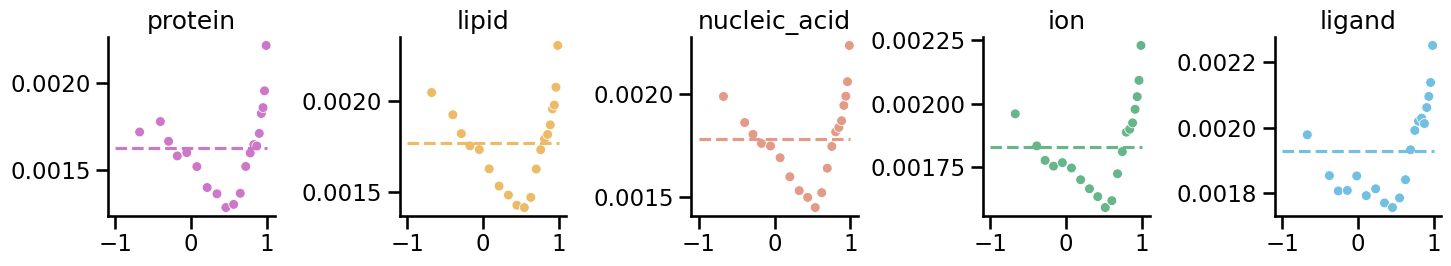

In [79]:
colors = {
    "ion": "#67B58A",
    "ligand": "#72BFE1",
    "lipid": "#ECBB67",
    "nucleic_acid": "#E29B86",
    "protein": "#CC77C8",
}
agg_results = agg_results.dropna().copy()
agg_results['quantile_bin_lower'] = agg_results['quantile_bin'].apply(lambda x: float(x.split(",")[0].split("[")[1]))
agg_results['quantile_bin_upper'] = agg_results['quantile_bin'].apply(lambda x: float(x.split(",")[1].split(")")[0]))
agg_results['quantile_bin_midpoint'] = (agg_results['quantile_bin_lower'] + agg_results['quantile_bin_upper']) / 2

agg_results['fold_change'] = agg_results.apply(lambda x: x['mean'] / overall_probability[overall_probability['modality']==x['modality']]['probability'].iloc[0], axis=1)

agg_results = agg_results.sort_values(['modality', 'quantile_bin_midpoint'])

agg_results['percentile'] = 0.0
for modality in ['protein', 'lipid', 'nucleic_acid', 'ion', 'ligand']:
    total = agg_results[agg_results['modality'] == modality]['count'].sum()
    percentile_values = agg_results[agg_results['modality'] == modality]['count'].cumsum() / total
    agg_results.loc[agg_results['modality'] == modality, 'percentile'] = percentile_values

sns.set_context("talk")
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for i, modality in enumerate(['protein', 'lipid', 'nucleic_acid', 'ion', 'ligand']):
    sns.scatterplot(data=agg_results[agg_results['modality'] == modality], x='quantile_bin_midpoint', y='mean', hue='modality', ax=ax[i],
                    palette=colors, legend=False, s=50)
    sns.despine()
    ax[i].hlines(y=overall_probability[overall_probability['modality']==modality]['probability'].iloc[0],color=colors[modality],
                 xmin=-1, xmax=1, linestyles='dashed')
    ax[i].set_ylabel("") #P(pair of proteins in same disease)")
    ax[i].set_xlabel("") #Cosine similarity")
    ax[i].set_title(modality)
plt.tight_layout()
plt.show()

In [25]:
modality_cutoff = {
    "protein": 0.98,
    "lipid": 0.975,
    "nucleic_acid": 0.971,
    "ligand": 0.969,
    "ion": 0.963,
}

agg_results = []
overall_probability = []

for modality in ['protein', 'lipid', 'nucleic_acid', 'ion', 'ligand']:
    results = pd.read_csv(f"results/protein_pairs_{modality}.csv")
    cosine_similarity_cutoff = modality_cutoff[modality]
    cosine_similarity_cutoffs = [0, 0.25, 0.5, 0.6, 0.7, 0.8, 0.9, cosine_similarity_cutoff, 1.0]
    results['cosine_similarity_bin'] = pd.cut(results['cosine_similarity'], bins=cosine_similarity_cutoffs, right=False)
    results['cosine_similarity_bin'] = results['cosine_similarity_bin'].astype(str)
    statistics = results.groupby('cosine_similarity_bin')['disease_association'].agg(['mean', 'std', 'count']).reset_index()
    statistics['modality'] = modality
    agg_results.append(statistics)

    overall_probability.append({
        'modality': modality,
        'probability': results['disease_association'].mean(),
        'std': results['disease_association'].std(),
        'count': len(results),
    })
agg_results = pd.concat(agg_results)
overall_probability = pd.DataFrame(overall_probability)

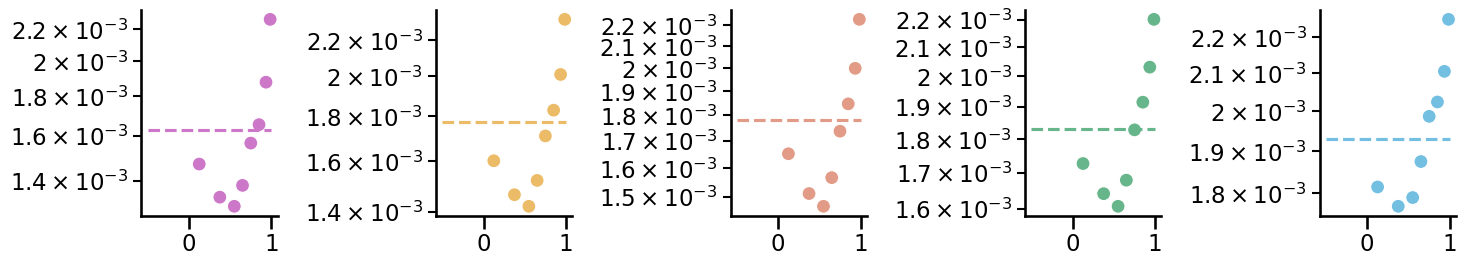

In [26]:
colors = {
    "ion": "#67B58A",
    "ligand": "#72BFE1",
    "lipid": "#ECBB67",
    "nucleic_acid": "#E29B86",
    "protein": "#CC77C8",
}
agg_results = agg_results[agg_results['cosine_similarity_bin'].astype(str)!='nan'].copy()
agg_results['cosine_similarity_bin_lower'] = np.concatenate([cosine_similarity_cutoffs[:-1] for _ in range(5)])  #gg_results['cosine_similarity_bin'].astype(str).apply(lambda x: float(x.split(",")[0].split("[")[1]))
agg_results['cosine_similarity_bin_upper'] = np.concatenate([cosine_similarity_cutoffs[1:] for _ in range(5)]) # agg_results['cosine_similarity_bin'].astype(str).apply(lambda x: float(x.split(",")[1].split(")")[0]))
agg_results['cosine_similarity_bin_midpoint'] = (agg_results['cosine_similarity_bin_lower'] + agg_results['cosine_similarity_bin_upper']) / 2

agg_results['fold_change'] = agg_results.apply(lambda x: x['mean'] / overall_probability[overall_probability['modality']==x['modality']]['probability'].iloc[0], axis=1)

agg_results = agg_results.sort_values(['modality', 'cosine_similarity_bin_midpoint'])

agg_results['percentile'] = 0.0
for modality in ['protein', 'lipid', 'nucleic_acid', 'ion', 'ligand']:
    total = agg_results[agg_results['modality'] == modality]['count'].sum()
    percentile_values = agg_results[agg_results['modality'] == modality]['count'].cumsum() / total
    agg_results.loc[agg_results['modality'] == modality, 'percentile'] = percentile_values

sns.set_context("talk")
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for i, modality in enumerate(['protein', 'lipid', 'nucleic_acid', 'ion', 'ligand']):
    sns.scatterplot(data=agg_results[agg_results['modality'] == modality], x='cosine_similarity_bin_midpoint', y='mean', hue='modality', ax=ax[i],
                    palette=colors, legend=False, s=100)
    sns.despine()
    ax[i].hlines(y=overall_probability[overall_probability['modality']==modality]['probability'].iloc[0],color=colors[modality],
                 xmin=-0.5, xmax=1, linestyles='dashed')
    ax[i].set_ylabel("") #P(pair of proteins in same disease)")
    ax[i].set_xlabel("") #Cosine similarity")
    ax[i].set_yscale('log')
    # ax[i].set_xlim(0, 1)
    # ax[i].set_title(modality)

plt.tight_layout()
plt.show()

Text(0, 0.5, '')

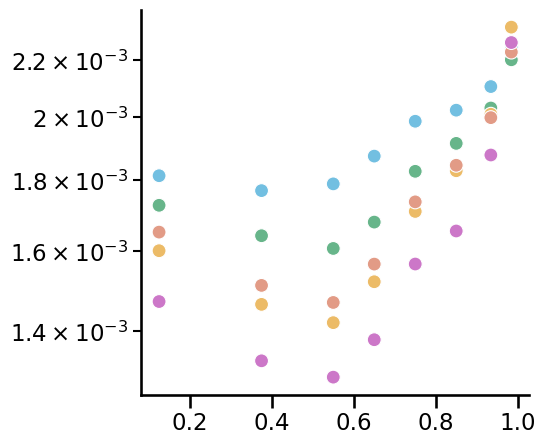

In [32]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=agg_results, x='cosine_similarity_bin_midpoint', y='mean', hue='modality', palette=colors, s=100, legend=False)
sns.despine()
plt.yscale('log')
plt.xlabel("")
plt.ylabel("")

# Repeat the above plot but separate out disease categories

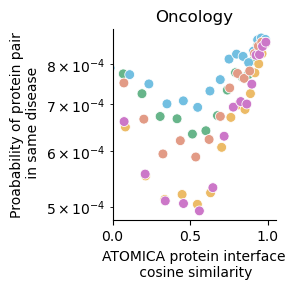

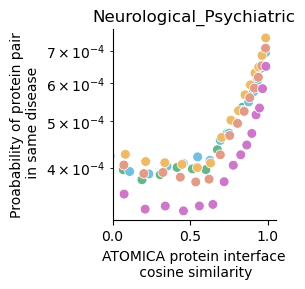

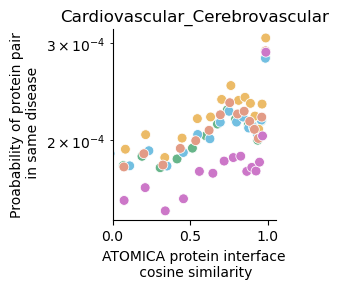

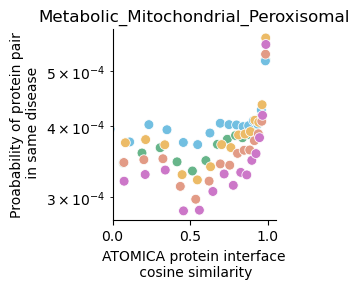

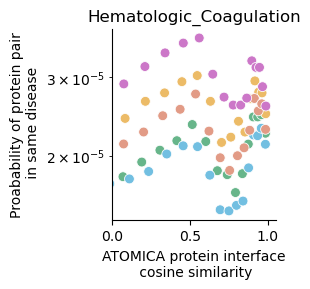

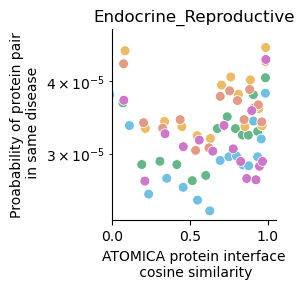

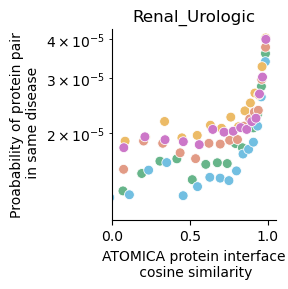

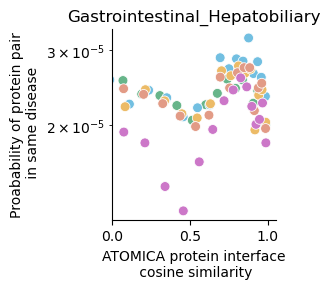

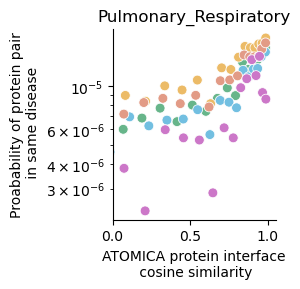

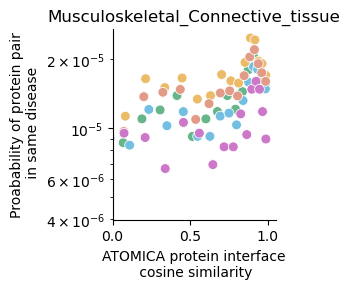

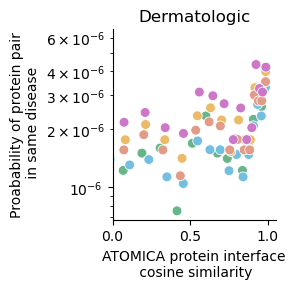

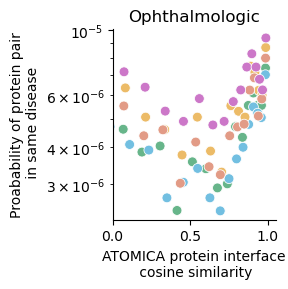

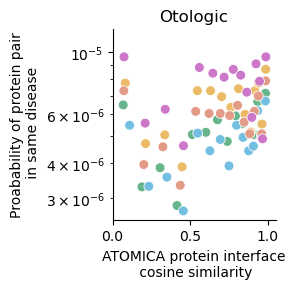

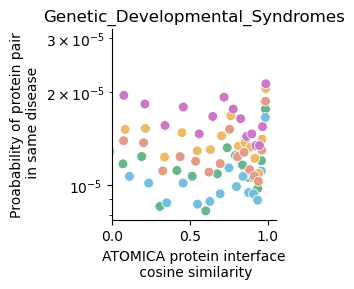

In [53]:
from disease_categorisation import disease_categories

for disease_category in disease_categories:
    agg_results = pd.read_csv(f"results/protein_pairs_cosine_binned_statistics_70_70_{disease_category}.csv")
    colors = {
        "ion": "#67B58A",
        "ligand": "#72BFE1",
        "lipid": "#ECBB67",
        "nucleic_acid": "#E29B86",
        "protein": "#CC77C8",
    }
    agg_results = agg_results[agg_results['quantile_bin'].astype(str)!='nan'].copy()
    agg_results['quantile_bin_lower'] = agg_results['quantile_bin'].str.split(",").str[0].str[1:].astype(float)
    agg_results['quantile_bin_upper'] = agg_results['quantile_bin'].str.split(",").str[1].str[1:-1].astype(float)
    agg_results['quantile_bin_midpoint'] = (agg_results['quantile_bin_lower'] + agg_results['quantile_bin_upper']) / 2

    # agg_results['fold_change'] = agg_results.apply(lambda x: x['mean'] / overall_probability[overall_probability['modality']==x['modality']]['probability'].iloc[0], axis=1)

    agg_results = agg_results.sort_values(['modality', 'quantile_bin_midpoint'])

    agg_results['percentile'] = 0.0
    for modality in ['protein', 'lipid', 'nucleic_acid', 'ion', 'ligand']:
        total = agg_results[agg_results['modality'] == modality]['count'].sum()
        percentile_values = agg_results[agg_results['modality'] == modality]['count'].cumsum() / total
        agg_results.loc[agg_results['modality'] == modality, 'percentile'] = percentile_values

    plt.figure(figsize=(3,3))
    plt.xlim(0,1.05)
    sns.scatterplot(data=agg_results, x='quantile_bin_midpoint', y='mean', hue='modality', palette=colors, s=50, legend=False)
    sns.despine()
    plt.yscale('log')
    plt.xlabel("ATOMICA protein interface\n cosine similarity")
    plt.ylabel("Proabability of protein pair\n in same disease")
    plt.title(disease_category)
    plt.tight_layout()
    plt.show()

# Size of disease pathway for similar vs dissimilar edges

In [3]:
def create_similarity_graph(similarity_matrix: np.ndarray, 
                          k: int = 50, 
                          min_similarity: Optional[float] = None) -> nx.Graph:
    """
    Create an undirected graph where each node is connected to its k most similar nodes,
    and all edges have a similarity greater than or equal to min_similarity.
    
    Args:
        similarity_matrix: A square numpy array containing similarity scores
        k: Number of most similar neighbors to connect (default: 50)
        min_similarity: Minimum similarity threshold for edges (default: None)
    
    Returns:
        NetworkX undirected graph
    """
    # Ensure the similarity matrix is square
    n = similarity_matrix.shape[0]
    assert similarity_matrix.shape == (n, n), "Similarity matrix must be square"
    
    # Create empty graph
    G = nx.Graph()
    
    # Add all nodes to the graph
    G.add_nodes_from(range(n))
    
    # For each node, find its k most similar neighbors
    # Use argpartition for efficiency (partial sort)
    for i in range(n):
        # Get similarities for current node
        similarities = similarity_matrix[i]
        
        # We don't want to include the node itself
        similarities[i] = -np.inf
        
        # Get indices of k largest similarities
        top_k_indices = np.argsort(similarities)[::-1][:k]
        
        # Filter by minimum similarity if specified
        if min_similarity is not None:
            top_k_indices = top_k_indices[similarities[top_k_indices] >= min_similarity]
        
        # Add edges
        for j in top_k_indices:
            if G.degree(i) < k and G.degree(j) < k:
                G.add_edge(i, j)
    
    print("Max degree:", max([G.degree(node) for node in G.nodes]))
    
    return G

In [ ]:
# cosine similarity cut offs for 90% of the nodes to belong to the giant connected component
most_similar_modality_cutoff = {
    "protein": 0.98,
    "lipid": 0.975,
    "nucleic_acid": 0.971,
    "ligand": 0.969,
    "ion": 0.963,
}

modality_cutoff = {
    "protein": 0,
    "lipid": 0,
    "nucleic_acid": 0,
    "ligand": 0,
    "ion": 0,
}


modality_graphs = {}

for modality, cutoff in modality_cutoff.items():
    similarity_matrices = []
    uniprot_to_node_idxs = []
    for embeddings_data_dir in embeddings_data_dirs:
        with open(os.path.join(embeddings_data_dir, f"pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_{modality}.pkl"), "rb") as f:
            embeddings_dataset = pickle.load(f)

        embeddings = np.array([x['graph_embedding'] for x in embeddings_dataset])
        uniprot_to_node_idx = {x['id']: i for i, x in enumerate(embeddings_dataset)}
        uniprot_to_node_idxs.append(uniprot_to_node_idx)

        similarity_matrix = cosine_similarity(embeddings)
        # remove the most similar edges, only keep the edges that are less similar than the median similarity
        median_val = np.median(similarity_matrix[np.triu_indices(similarity_matrix.shape[0], k=1)])
        similarity_matrix[similarity_matrix > median_val] = -np.inf
        similarity_matrices.append(similarity_matrix)
    
    assert list(uniprot_to_node_idxs[0].keys()) == list(uniprot_to_node_idxs[1].keys()) == list(uniprot_to_node_idxs[2].keys())
    similarity_matrix = np.mean(similarity_matrices, axis=0)

    indices = np.triu_indices_from(similarity_matrix, k=1)
    filtered_indices = indices[0][similarity_matrix[indices] > cutoff], indices[1][similarity_matrix[indices] > cutoff]

    print(f"-----------------{modality}-----------------")
    print("Number of embeddings: ", embeddings.shape)
    print("num edges: ", filtered_indices[0].shape[0])

    G = create_similarity_graph(similarity_matrix, k=50, min_similarity=cutoff)
    num_connected_components = nx.number_connected_components(G)
    size_of_largest_connected_component = max([len(x) for x in nx.connected_components(G)])
    whole_graph_density = nx.density(G)
    whole_graph_clustering = nx.average_clustering(G)
    print("size of largest connected component: ", size_of_largest_connected_component)
    print("proportion of largest connected component: ", size_of_largest_connected_component / len(embeddings))
    print("number of connected components", num_connected_components)
    print("density: ", whole_graph_density)
    print("clustering: ", whole_graph_clustering)
    print("average degree: ", np.mean([x[1] for x in G.degree()]))

    largest_component = max(nx.connected_components(G), key=len)
    largest_component_subgraph = G.subgraph(largest_component).copy()
    G = largest_component_subgraph

    adjacency_matrix = similarity_matrix > cutoff
    adjacency_matrix = adjacency_matrix.astype(int)
    largest_component_indices = sorted(list(largest_component))
    largest_component_adj_matrix = adjacency_matrix[np.ix_(largest_component_indices, largest_component_indices)]

    modality_graphs[modality] = {
        "graph": G,
        "uniprot_to_node_idx": uniprot_to_node_idx,
        "largest_component": largest_component,
        "filtered_indices": filtered_indices,
        "adjacency_matrix": largest_component_adj_matrix,
    }

-----------------protein-----------------
Number of embeddings:  (17158, 32)
num edges:  21975651
Max degree: 50
size of largest connected component:  13910
proportion of largest connected component:  0.8107005478493997
number of connected components 3249
density:  0.0011137176984212021
clustering:  0.0001571940339876553
average degree:  19.108054551812565
-----------------lipid-----------------
Number of embeddings:  (6766, 32)
num edges:  2805824
Max degree: 50
size of largest connected component:  6444
proportion of largest connected component:  0.9524091043452557
number of connected components 323
density:  0.0037047548074706825
clustering:  7.082004840000932e-05
average degree:  25.062666272539165
-----------------nucleic_acid-----------------
Number of embeddings:  (6649, 32)
num edges:  2763712
Max degree: 50
size of largest connected component:  5915
proportion of largest connected component:  0.8896074597683862
number of connected components 735
density:  0.0034149611995253123

In [52]:
def get_disease_connectivity(modality, disease_id, modality_graphs):
    G = modality_graphs[modality]['graph'].copy()
    uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
    node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
    largest_component = modality_graphs[modality]['largest_component']

    filtered_relations_df = disease_associations[disease_associations['diseaseId'] == disease_id].copy()
    number_of_disease_proteins = len(filtered_relations_df['uniprot_targetId'].unique())
    filtered_relations_df['node_idx'] = filtered_relations_df['uniprot_targetId'].map(uniprot_to_node_idx).fillna(-1).astype(int)
    filtered_relations_df = filtered_relations_df[(filtered_relations_df['node_idx'] != -1) & (filtered_relations_df['node_idx'].isin(largest_component))].copy()
    selected_disease_nodes = filtered_relations_df['node_idx'].tolist()

    if len(selected_disease_nodes) == 0:
        return {"modality": modality, "diseaseId": disease_id, "size_of_largest_connected_component": 0, 
                "number_of_nodes": 0, "size_of_largest_pathway_component": 0, "num_components": 0, 
                "density": 0, "clustering": 0, "proteins_in_largest_component": []}

    subgraph = G.subgraph(selected_disease_nodes)

    components = sorted(nx.connected_components(subgraph), key=len, reverse=True)

    largest_component = components[0]
    size_of_largest_component = len(largest_component)

    subgraph_num_components = nx.number_connected_components(subgraph)
    subgraph_density = nx.density(subgraph)
    subgraph_clustering = nx.average_clustering(subgraph)
    number_of_nodes = len(selected_disease_nodes)
    proteins = [node_idx_to_uniprot[x] for x in largest_component]
    all_proteins = [node_idx_to_uniprot[x] for x in selected_disease_nodes]
    
    return {"modality": modality, "diseaseId": disease_id, "size_of_largest_connected_component": size_of_largest_component, 
            "number_of_nodes": number_of_nodes, "relative_size_of_largest_pathway_component": size_of_largest_component/number_of_nodes, 
            "relative_size_of_number_of_nodes": number_of_nodes/number_of_disease_proteins,
            "num_components": subgraph_num_components, "density": subgraph_density, "clustering": subgraph_clustering,
            "proteins_in_largest_component": proteins, 'all_proteins': all_proteins, 'components': components}

In [53]:
disease_connectivity = []
for disease_id in tqdm(disease_associations['diseaseId'].unique(), total=len(disease_associations['diseaseId'].unique())):
    for modality in modality_graphs:
        disease_connectivity.append(get_disease_connectivity(modality, disease_id, modality_graphs))
disease_connectivity_df = pd.DataFrame(disease_connectivity)
disease_connectivity_df['diseaseName'] = disease_connectivity_df['diseaseId'].map(disease_id_to_name)
disease_connectivity_df[disease_connectivity_df['number_of_nodes']>=25].sort_values('num_components', ascending=True)

100%|██████████| 82/82 [01:43<00:00,  1.26s/it]


,modality,diseaseId,size_of_largest_connected_component,number_of_nodes,relative_size_of_largest_pathway_component,relative_size_of_number_of_nodes,num_components,density,clustering,proteins_in_largest_component,all_proteins,components,diseaseName
399,ion,MONDO_0019064,3,25,0.120000,0.384615,21,0.013333,0.0,"[Q8N819, Q8TCG5, Q96IR7]","[P54886, Q9HCG7, Q68DK2, P49902, Q8IYU2, Q9NZD...","[{618, 4540, 3742}, {5762, 5910}, {3641, 3833}...",hereditary spastic paraplegia
242,nucleic_acid,EFO_0009533,3,26,0.115385,0.220339,23,0.009231,0.0,"[Q99578, O75569, Q6NSJ0]","[Q9BVS4, P49841, O00591, P17568, Q13615, Q0463...","[{490, 5251, 5487}, {2613, 5095}, {1795}, {499...",basal ganglia disease
308,ligand,EFO_0001378,2,25,0.080000,0.480769,24,0.003333,0.0,"[P01111, Q969S8]","[P28907, P22607, Q9UBN7, Q969S8, Q9H4B7, P0039...","[{4696, 898}, {5259}, {3471}, {5393}, {5527}, ...",multiple myeloma
378,ligand,MONDO_0024615,2,26,0.076923,0.577778,24,0.006154,0.0,"[Q14181, P49643]","[Q14181, Q9UBN7, Q969S8, P56282, Q9H4B7, P0988...","[{1707, 1316}, {3116, 3068}, {5376}, {898}, {4...",T-cell and NK-cell neoplasm
4,ion,MONDO_0015909,2,26,0.076923,0.406250,24,0.006154,0.0,"[Q8N554, Q9NZK5]","[P60866, P38398, P07992, Q06609, Q9NZK5, P1597...","[{297, 4780}, {5576, 3054}, {778}, {3487}, {42...",aplastic anemia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,lipid,EFO_0000474,4,134,0.029851,0.501873,122,0.001347,0.0,"[Q15822, Q9P0X4, O15228, O43525]","[P35499, Q9NY47, Q9BRB3, Q9P0K1, P34903, O0011...","[{6273, 3620, 4278, 4111}, {6097, 4643, 3741, ...",epilepsy
350,protein,EFO_0000400,2,127,0.015748,0.641414,123,0.000500,0.0,"[Q96RI1, P27487]","[O14561, P30988, Q09428, P48546, P31629, Q96RI...","[{14084, 16287}, {1867, 10523}, {798, 3967}, {...",diabetes mellitus
5,protein,EFO_0000474,3,164,0.018293,0.614232,148,0.001197,0.0,"[O60337, O75746, O00591]","[Q96QS3, O43497, Q9NY47, P17600, O76039, Q9P0K...","[{3000, 13850, 13435}, {14480, 14746, 6179}, {...",epilepsy
35,protein,EFO_0000574,2,168,0.011905,0.567568,161,0.000499,0.0,"[P13639, Q4VC05]","[Q92851, P28907, Q92793, P40259, P20273, Q1418...","[{11969, 87}, {13437, 16021}, {984, 12436}, {1...",lymphoma


In [54]:
similar_disease_connectivity = []
for disease_id in tqdm(disease_associations['diseaseId'].unique(), total=len(disease_associations['diseaseId'].unique())):
    for modality in modality_graphs:
        similar_disease_connectivity.append(get_disease_connectivity(modality, disease_id, similar_modality_graphs))
similar_disease_connectivity_df = pd.DataFrame(similar_disease_connectivity)
similar_disease_connectivity_df['diseaseName'] = similar_disease_connectivity_df['diseaseId'].map(disease_id_to_name)
similar_disease_connectivity_df[similar_disease_connectivity_df['number_of_nodes']>=25].sort_values('num_components', ascending=True)

  0%|          | 0/82 [00:00<?, ?it/s]

100%|██████████| 82/82 [02:06<00:00,  1.54s/it]


,modality,diseaseId,size_of_largest_connected_component,number_of_nodes,relative_size_of_largest_pathway_component,relative_size_of_number_of_nodes,num_components,density,clustering,proteins_in_largest_component,all_proteins,components,diseaseName
246,lipid,MONDO_0000774,31,43,0.720930,0.977273,9,0.109635,0.412925,"[Q14721, Q9ULD8, O43525, P22001, Q9NSA2, Q8TDN...","[Q9UIX4, P51787, Q12809, O43526, P22303, Q9UQ0...","[{6151, 1934, 4111, 536, 2461, 1316, 1192, 427...",autoimmune neuropathy
249,ion,MONDO_0000774,9,39,0.230769,0.886364,15,0.052632,0.244444,"[Q09470, Q9NR82, P16389, Q9NS40, Q9UQ05, P2245...","[Q9UIX4, P51787, O43526, Q9UQ05, Q9NSA2, Q96RP...","[{3972, 4358, 3975, 1265, 5655, 1400, 187, 642...",autoimmune neuropathy
111,lipid,MONDO_0004975,9,27,0.333333,0.500000,18,0.028490,0.061728,"[Q14957, Q12879, P04035, P12821, Q8TCU5, Q0558...","[Q30201, Q9UKA4, Q8WTV0, P35354, P49768, P2230...","[{5796, 6183, 4332, 5932, 4047, 6097, 4882, 25...",Alzheimer disease
168,ligand,MONDO_0018997,4,27,0.148148,0.574468,18,0.028490,0.086420,"[P61224, P62070, Q92963, P62834]","[P27448, P60709, P10398, Q8N653, P28482, P2736...","[{2888, 3891, 4925, 4623}, {5833, 3426, 3297, ...",Noonan syndrome
194,ion,EFO_0004251,5,25,0.200000,0.462963,19,0.020000,0.000000,"[P12931, P08631, P06241, P07948, O96017]","[P09769, P06241, O60674, P08631, P52333, Q1591...","[{6441, 4300, 6395, 476, 5597}, {6113, 6391}, ...",myeloproliferative disorder
...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,protein,EFO_0000400,6,160,0.037500,0.808081,129,0.002437,0.000000,"[O95182, O75489, Q07343, O43674, O00217, O95168]","[O14561, P30988, Q09428, P35499, Q92481, P4854...","[{5221, 13415, 14383, 7441, 16786, 2003}, {361...",diabetes mellitus
295,protein,MONDO_0004736,6,180,0.033333,0.750000,139,0.002669,0.025926,"[O94906, P24386, P30038, Q8IWN7, Q16719, Q9BY12]","[Q9UDR5, Q8TBB6, P82251, P00480, Q9P0W8, O7566...","[{12738, 15202, 10489, 13929, 16857, 12249}, {...",inborn disorder of amino acid metabolism
5,protein,EFO_0000474,8,220,0.036364,0.823970,150,0.003196,0.058333,"[Q01118, Q9H3T3, O15399, Q99250, Q14683, Q1279...","[Q96QS3, P35499, Q9NY47, Q9BRB3, P17600, O7603...","[{16609, 2050, 14051, 11496, 16302, 12754, 154...",epilepsy
35,protein,EFO_0000574,5,204,0.024510,0.689189,161,0.002173,0.026144,"[Q01118, Q99250, O14497, P46527, Q9Y5Y9]","[Q92851, P40259, P35499, P20273, Q14181, P2544...","[{16609, 11496, 13704, 13329, 15415}, {11585, ...",lymphoma


In [55]:
connectivity_mask = (similar_disease_connectivity_df['number_of_nodes']>=25) & (disease_connectivity_df['number_of_nodes']>=25)
disease_connectivity_df = disease_connectivity_df[connectivity_mask]
similar_disease_connectivity_df = similar_disease_connectivity_df[connectivity_mask]

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

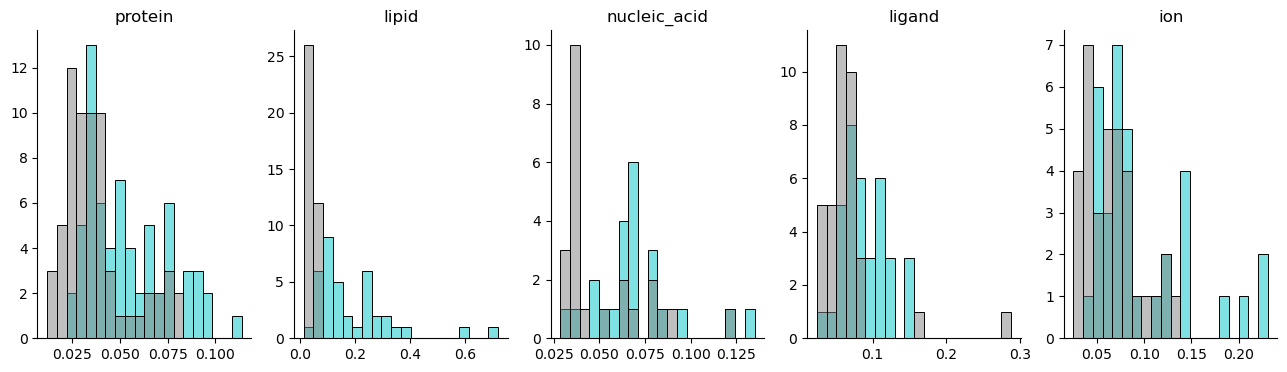

In [70]:
plot_df = {
    "relative_size_of_largest_pathway_component": disease_connectivity_df['relative_size_of_largest_pathway_component'].tolist() + similar_disease_connectivity_df['relative_size_of_largest_pathway_component'].tolist(),
    "modality": disease_connectivity_df['modality'].tolist() + similar_disease_connectivity_df['modality'].tolist(),
    "group": ["least similar"] * len(disease_connectivity_df) + ["most similar"] * len(similar_disease_connectivity_df)
}
plot_df = pd.DataFrame(plot_df)

model_colors = {
    "most similar": "#00C4C7",
    "least similar": "#808080"
}

fig, ax = plt.subplots(1,5, figsize=(16, 4))

for i, modality in enumerate(modality_graphs):
    num_diseases = disease_connectivity_df[disease_connectivity_df['modality'] == modality]['diseaseId'].nunique()
    sns.histplot(data=plot_df[plot_df['modality'] == modality], x="relative_size_of_largest_pathway_component", hue="group", bins=20, palette=model_colors, ax=ax[i], legend=False)
    sns.despine()
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
    ax[i].set_title(modality)